In [1]:
import torch
from torch.utils.data import DataLoader
from torch import nn
import torch.optim as optim
import torchvision.models as models

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'functions')))
from dataset import ChestXrayDataset
from train import train
from evaluation import plot_results ,eval_on_metrics

In [2]:
IMAGE_PATH = "../archive/"
import glob

# Tüm alt klasörlerdeki jpg ve png dosyalarını alalım
image_paths = glob.glob(IMAGE_PATH + "**/images/*.[jp][pn]g", recursive=True)

print(f"Toplam {len(image_paths)} resim bulundu.")

Toplam 112120 resim bulundu.


In [3]:
TRAIN_PATH = '../data/AP_PA_Train.xlsx'
TEST_PATH = '../data/AP_PA_Test.xlsx'
VAL_PATH = '../data/AP_PA_Validation.xlsx'

In [4]:
num_classes = 2
EPOCHS = 30

In [5]:
import torch
import torch.nn as nn
from torchvision import models
from huggingface_hub import hf_hub_download

# 1. Modeli İndir
repo_id = "Lab-Rasool/RadImageNet"
filename = "ResNet50.pt"
model_path = hf_hub_download(repo_id=repo_id, filename=filename)

# 2. İskeleti Oluştur (Boş ResNet50)
# pretrained=False yapıyoruz çünkü ağırlıkları biz yükleyeceğiz.
model = models.resnet50(pretrained=False)

# 3. Ağırlık Dosyasını (Checkpoint) Yükle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(model_path, map_location=device)

# --- KRİTİK DÜZELTME: "module." önekini temizleme ---
# RadImageNet genellikle çoklu GPU ile eğitildiği için anahtar isimleri "module." ile başlayabilir.
# Tek GPU veya CPU'da çalışmak için bunları temizlememiz gerekir.
state_dict = checkpoint  # Eğer checkpoint içinde 'state_dict' anahtarı varsa: checkpoint['state_dict']

# Anahtarlardaki 'module.' kelimesini temizleyerek yeni bir sözlük oluşturuyoruz
new_state_dict = {}
for k, v in state_dict.items():
    name = k.replace("module.", "") # 'module.layer1' -> 'layer1' olur
    new_state_dict[name] = v

# Temizlenmiş ağırlıkları modele yükle
try:
    model.load_state_dict(new_state_dict, strict=False)
    print("RadImageNet ağırlıkları başarıyla yüklendi!")
except RuntimeError as e:
    print(f"Model yüklenirken hata oluştu: {e}")
# ----------------------------------------------------

# 4. TÜM parametreleri dondur (Backbone Freezing)
for param in model.parameters():
    param.requires_grad = False

# 5. Son Katmanı Değiştir (Cinsiyet Tespiti için 2 Sınıf)
# Bu yeni katman otomatik olarak requires_grad=True olur.
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) 

model = model.to(device)

# KONTROL: Sadece son katmanın eğitileceğini doğrulama
print("\nEğitilecek katmanlar:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"\t {name}")  # Çıktı sadece fc.weight ve fc.bias olmalı

print("\nModel ince ayar (fine-tuning) için hazır.")

c:\Users\Furkan\miniconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Furkan\miniconda3\envs\ml\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Furkan\miniconda3\envs\ml\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


RadImageNet ağırlıkları başarıyla yüklendi!

Eğitilecek katmanlar:
	 fc.weight
	 fc.bias

Model ince ayar (fine-tuning) için hazır.


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
print(device)

cuda


In [7]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [8]:
train_dataset = ChestXrayDataset(TRAIN_PATH, image_paths,transform=transform)
val_dataset = ChestXrayDataset(TEST_PATH,image_paths, transform=transform)
test_dataset = ChestXrayDataset(VAL_PATH,image_paths, transform=transform)

In [9]:
print("Train size : ",len(train_dataset))
print("Validation size : ",len(val_dataset))
print("Test size : ",len(test_dataset))

Train size :  78566
Validation size :  16491
Test size :  17063


In [10]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True,num_workers=10)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True,num_workers=10)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True,num_workers=10)

In [11]:
train_losses, train_accuracies, val_losses, val_accuracies = train(model, train_dataloader, val_dataloader, criterion, optimizer, device,num_epochs=EPOCHS,save_path='models/radimagenet_resnet50_finetuned.pth')

Epoch 1/30 - Validation: 100%|██████████| 258/258 [00:43<00:00,  5.97it/s]


Epoch [1/30]
  Train Loss: 0.5014, Train Acc: 0.7641
  Val   Loss: 0.3887, Val   Acc: 0.8279
  Best model saved with val_loss: 0.3887


Epoch 2/30 - Validation: 100%|██████████| 258/258 [00:49<00:00,  5.17it/s]


Epoch [2/30]
  Train Loss: 0.3629, Train Acc: 0.8542
  Val   Loss: 0.3081, Val   Acc: 0.8952
  Best model saved with val_loss: 0.3081


Epoch 3/30 - Validation: 100%|██████████| 258/258 [00:42<00:00,  6.00it/s]


...

Epoch [28/30]
  Train Loss: 0.2103, Train Acc: 0.9231
  Val   Loss: 0.1899, Val   Acc: 0.9360
  Best model saved with val_loss: 0.1899


Epoch 29/30 - Validation: 100%|██████████| 258/258 [00:47<00:00,  5.41it/s]


Epoch [29/30]
  Train Loss: 0.2149, Train Acc: 0.9206
  Val   Loss: 0.2046, Val   Acc: 0.9240


Epoch 30/30 - Validation: 100%|██████████| 258/258 [00:47<00:00,  5.44it/s]

Epoch [30/30]
  Train Loss: 0.2125, Train Acc: 0.9221
  Val   Loss: 0.1864, Val   Acc: 0.9369
  Best model saved with val_loss: 0.1864


In [12]:
print(f"num_epochs: {EPOCHS}")
print(f"train_losses: {len(train_losses)}")
print(f"val_losses: {len(val_losses)}")
print(f"train_accuracies: {len(train_accuracies)}")
print(f"val_accuracies: {len(val_accuracies)}")


num_epochs: 30
train_losses: 30
val_losses: 30
train_accuracies: 30
val_accuracies: 30


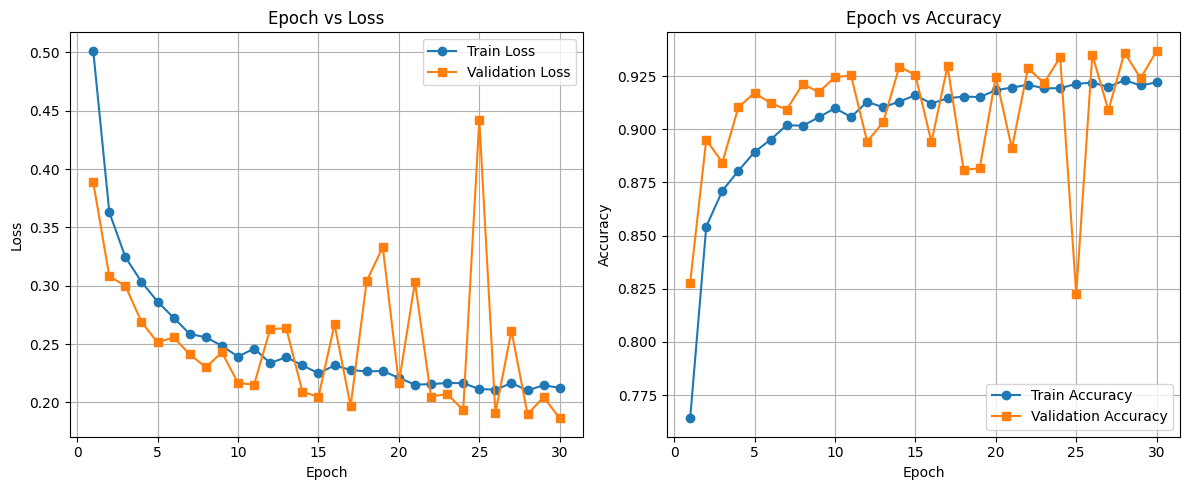

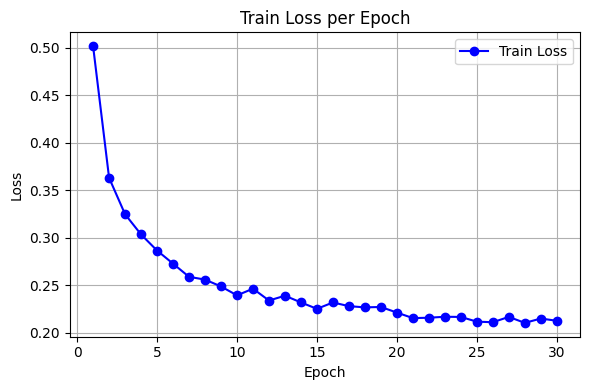

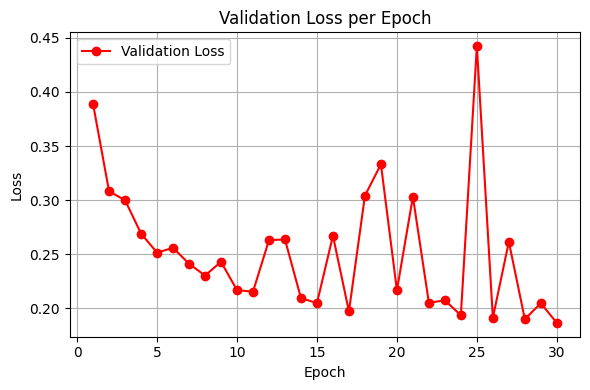

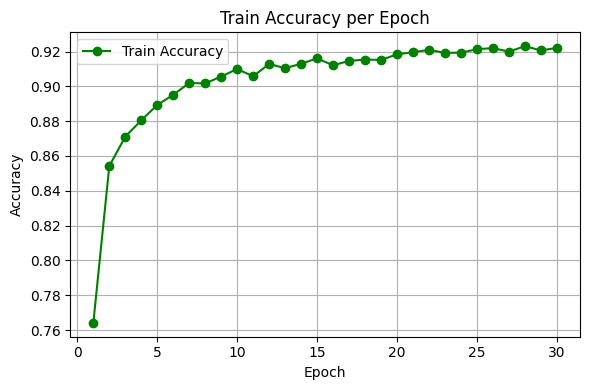

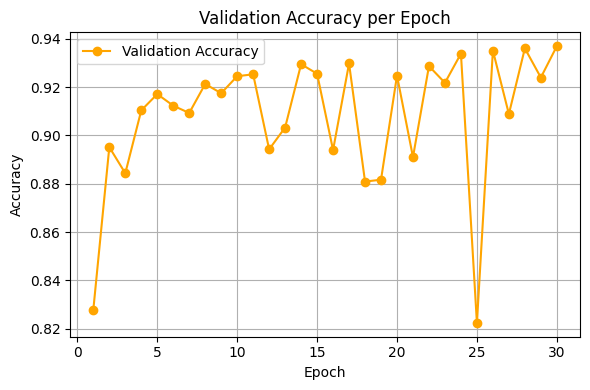

In [14]:
plot_results(30, train_losses, train_accuracies, val_losses, val_accuracies)

Evaluating: 100%|██████████| 267/267 [00:50<00:00,  5.26it/s]

Precision: 0.9491
Recall:    0.9446
F1 Score:  0.9469
AUC:       0.9792


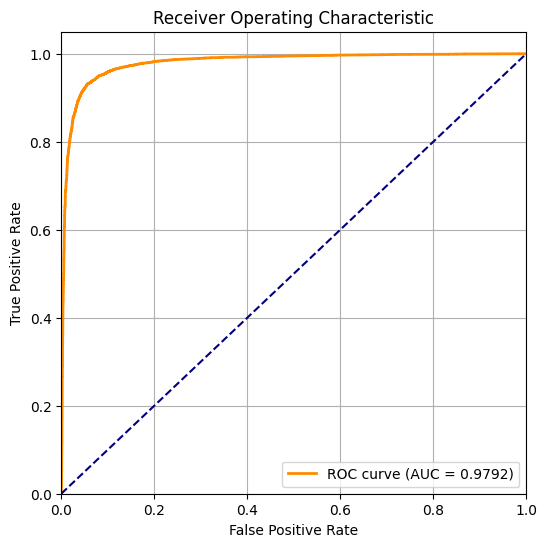

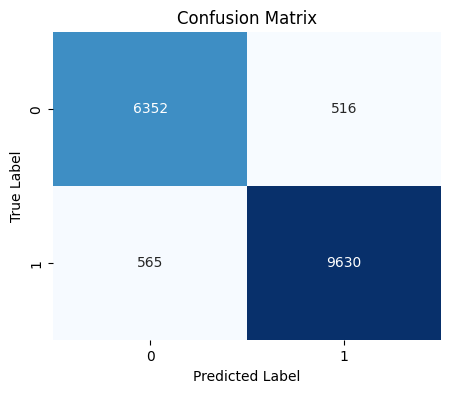

In [15]:
eval_on_metrics(model, test_dataloader)